# maximal drought extent

In [1]:
import xarray as xr

from analyses.utils import (
    get_max_cluster_area_from_binary_image,
    get_image_count_labeled_connected_components,
    get_image_labeled_largest_connected_component,
)

import cmcrameri as cmc  # noqa: F401

from metpy.units import units
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import cartopy.crs as ccrs

from unseen_awg.plotting_utils import (
    add_headers,
    map_plot_without_frame_with_bounds,
    add_label_to_axes,
)
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

import os
import yaml

In [2]:
mpl.rc_file("../../matplotlibrc")
ALPHABET = "abcdefghijk"

In [3]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [4]:
YEAR_MIN = 2003
N_YEARS = 21
YEAR_MAX = YEAR_MIN + N_YEARS - 1
QUANTILES = xr.DataArray([0.2, 0.10, 0.05])

N_MONTHS_ROLLING = 12

USE_ANOMALIES = False
USE_LSM = True

In [5]:
path_era5_rechunk = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_impact_variables_era5/combined_facc0e91.zarr",
)

path_clim_era5 = os.path.join(
    paths["dir_preprocessed_datasets"],
    "climatology_preprocessed_impact_variables_era5/combined_facc0e91_245a2015.nc",
)

path_clim_wg = os.path.join(
    paths["dir_preprocessed_datasets"],
    "climatology_preprocessed_impact_variables_reforecasts/combined-corrected_facc0e91_7d1d3d97_884a804a_3f7e331d_245a2015.nc",
)

tp = xr.open_dataset(
    path_era5_rechunk,
    decode_timedelta=True,
)["tp"]
tp = tp.assign_coords({"valid_time": tp.init_time + tp.lead_time})

tp = tp.where(tp.metpy.quantify() > 1 * units.millimeter, 0).metpy.dequantify()

lsm = xr.open_dataset(paths["path_lsm"])["lsm"]
lsm = (lsm > 0.5).squeeze().drop_vars(("valid_time", "number"))

clim_tp = xr.open_dataset(path_clim_era5)["tp"]
clim_tp = clim_tp.assign_coords(dayofyear=("dayofyear", np.arange(1, 367)))

# currently this isn't used...
clim_tp_re = xr.open_dataset(path_clim_wg)["tp"]
clim_tp_re = clim_tp_re.assign_coords(dayofyear=("dayofyear", np.arange(1, 367)))

In [7]:
dir_runs = os.path.join(
    paths["dir_results"], "rolling_droughts/5e06172f_f40e9460_1e69bda9_d13ad10f"
)

In [8]:
run = "False_12_b6e7334d_fc69af3a"  # no anomalies, 12 months, sigma 2.5

tp_rolling_gt = xr.open_dataarray(
    os.path.join(os.path.join(dir_runs, run, "quantiles_gt.nc"))
)
tp_rolling_wg = xr.open_dataarray(os.path.join(dir_runs, run, "quantiles_wg.nc"))

In [9]:
area_weights = np.cos(np.deg2rad(tp_rolling_gt.latitude))
area_weights.name = "area_weights"
area_weights = area_weights.expand_dims(
    {"longitude": tp_rolling_gt.longitude.data}, axis=-1
)
# normalize their sum to 1:
area_weights = area_weights / area_weights.sum()

In [10]:
# fraction of land area:
fraction_land = np.sum(area_weights.data[lsm.data])

In [11]:
quantiles_gt = tp_rolling_gt.quantile(QUANTILES, dim="time")
quantiles_wg = tp_rolling_wg.quantile(QUANTILES, dim=("time"))

/tmp/ipykernel_1134402/4096140617.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = plt.legend()


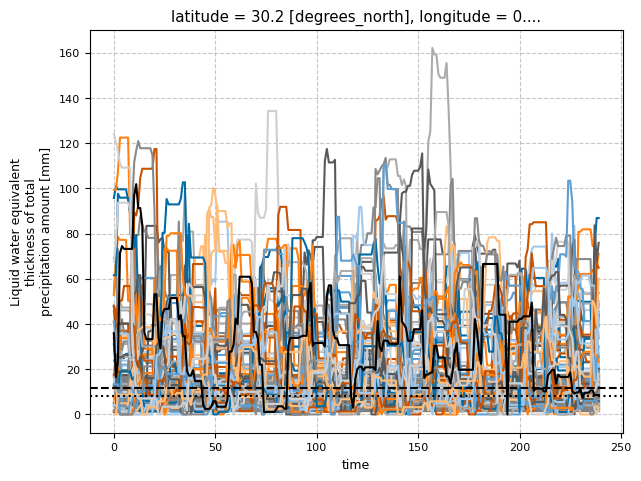

In [12]:
# for a single test location, test how (un-)realistic the generated time series is.

lat = 30  # 36.7538
lon = 0  # 3.0588

quantiles_sel_gt = tp_rolling_gt.sel(
    latitude=lat, longitude=lon, method="nearest"
).quantile(QUANTILES, dim="time")
quantiles_sel_wg = tp_rolling_wg.sel(
    latitude=lat, longitude=lon, method="nearest"
).quantile(QUANTILES, dim="time")

q = 0.2

tp_rolling_wg.sel(latitude=lat, longitude=lon, method="nearest").squeeze().isel(
    seed=slice(0, 50)
).plot(hue="seed")
tp_rolling_gt.sel(latitude=lat, longitude=lon, method="nearest").squeeze().plot(
    color="k"
)

plt.axhline(
    quantiles_sel_gt.sel(quantile=q, method="nearest"),
    color="k",
    linestyle="dashed",
)

plt.fill_between(
    tp_rolling_gt.time,
    quantiles_sel_wg.sel(quantile=q, method="nearest").min("seed").squeeze(),
    quantiles_sel_wg.sel(quantile=q, method="nearest").max("seed").squeeze(),
    color="gray",
)

plt.axhline(
    quantiles_wg.sel(latitude=lat, longitude=lon, quantile=q, method="nearest").mean(
        "seed"
    ),
    color="k",
    linestyle="dotted",
)

# Add a legend
legend = plt.legend()
legend.remove()

In [13]:
def binarize_then_get_max_cluster_area(tp, quantiles, lsm, area_weights, use_lsm=True):
    exceeding_quantile = tp < quantiles
    if use_lsm:
        exceeding_quantile[~lsm] = False
    return get_max_cluster_area_from_binary_image(exceeding_quantile, area_weights)

In [14]:
largest_cluster_area_gt = xr.apply_ufunc(
    binarize_then_get_max_cluster_area,
    tp_rolling_gt,
    quantiles_gt,
    lsm,
    area_weights,
    input_core_dims=[
        ["latitude", "longitude"],
        ["latitude", "longitude"],
        ["latitude", "longitude"],
        ["latitude", "longitude"],
    ],
    output_core_dims=[[]],
    vectorize=True,
)

largest_cluster_area_wg = xr.apply_ufunc(
    binarize_then_get_max_cluster_area,
    tp_rolling_wg,
    quantiles_wg,
    lsm,
    area_weights,
    input_core_dims=[
        ["latitude", "longitude"],
        ["latitude", "longitude"],
        ["latitude", "longitude"],
        ["latitude", "longitude"],
    ],
    output_core_dims=[[]],
    vectorize=True,
)

In [15]:
# images_wg = exceeding_quantile_wg.isel(largest_cluster_area_wg.argmax(("time", "seed")))
# images_gt = exceeding_quantile_gt.isel(time=largest_cluster_area_gt.argmax(("time")))

tp_rolling_wg_at_max = tp_rolling_wg.isel(time=largest_cluster_area_wg.argmax(("time")))

tp_rolling_gt_at_max = tp_rolling_gt.isel(largest_cluster_area_gt.argmax(("time",)))

images_wg = tp_rolling_wg_at_max < quantiles_wg
images_wg = images_wg.where(lsm, other=0)

images_gt = tp_rolling_gt_at_max < quantiles_gt
images_gt = images_gt.where(lsm, other=0)

overall_largest_cluster_area_wg = largest_cluster_area_wg.isel(
    largest_cluster_area_wg.argmax(("time", "seed"))
)
overall_largest_cluster_area_gt = largest_cluster_area_gt.isel(
    time=largest_cluster_area_gt.argmax(("time"))
)

In [16]:
labeled_images_wg, counts_wg = xr.apply_ufunc(
    get_image_count_labeled_connected_components,
    images_wg,
    input_core_dims=[["latitude", "longitude"]],
    output_core_dims=[["latitude", "longitude"], []],
    vectorize=True,
)

labeled_images_gt, counts_gt = xr.apply_ufunc(
    get_image_count_labeled_connected_components,
    images_gt,
    input_core_dims=[["latitude", "longitude"]],
    output_core_dims=[["latitude", "longitude"], []],
    vectorize=True,
)

In [17]:
labeled_images_wg_largest_component = xr.apply_ufunc(
    get_image_labeled_largest_connected_component,
    images_wg,
    area_weights,
    input_core_dims=[["latitude", "longitude"], ["latitude", "longitude"]],
    output_core_dims=[["latitude", "longitude"]],
    vectorize=True,
)

labeled_images_gt_largest_component = xr.apply_ufunc(
    get_image_labeled_largest_connected_component,
    images_gt,
    area_weights,
    input_core_dims=[["latitude", "longitude"], ["latitude", "longitude"]],
    output_core_dims=[["latitude", "longitude"]],
    vectorize=True,
)

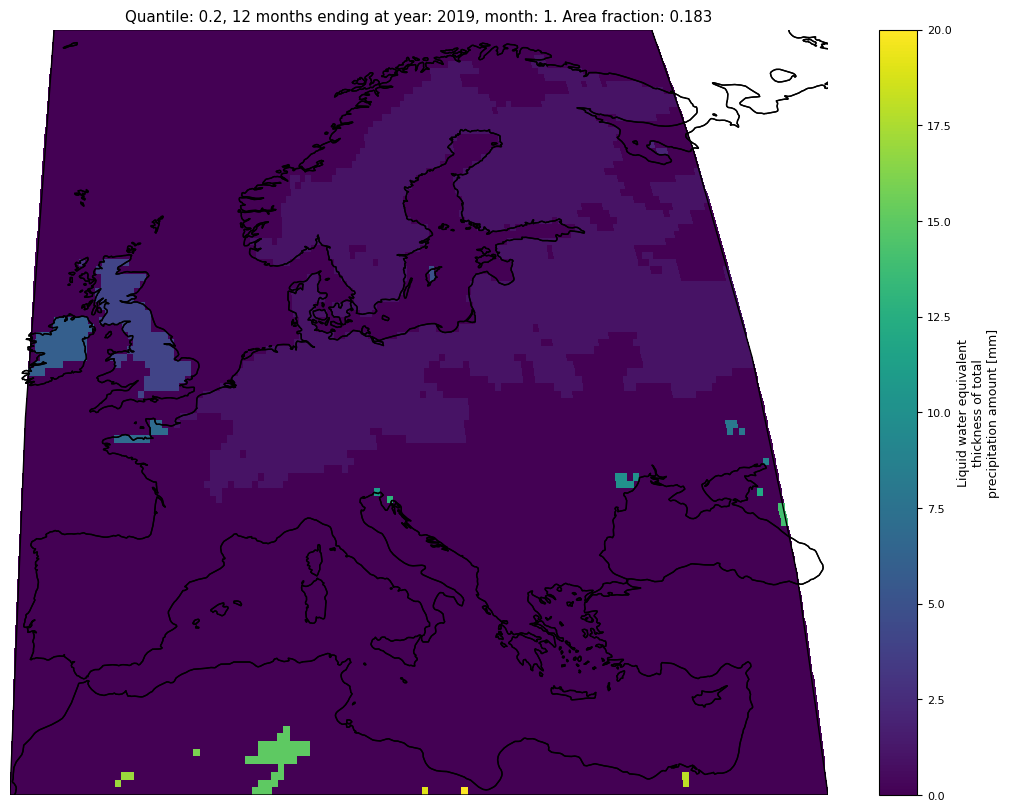

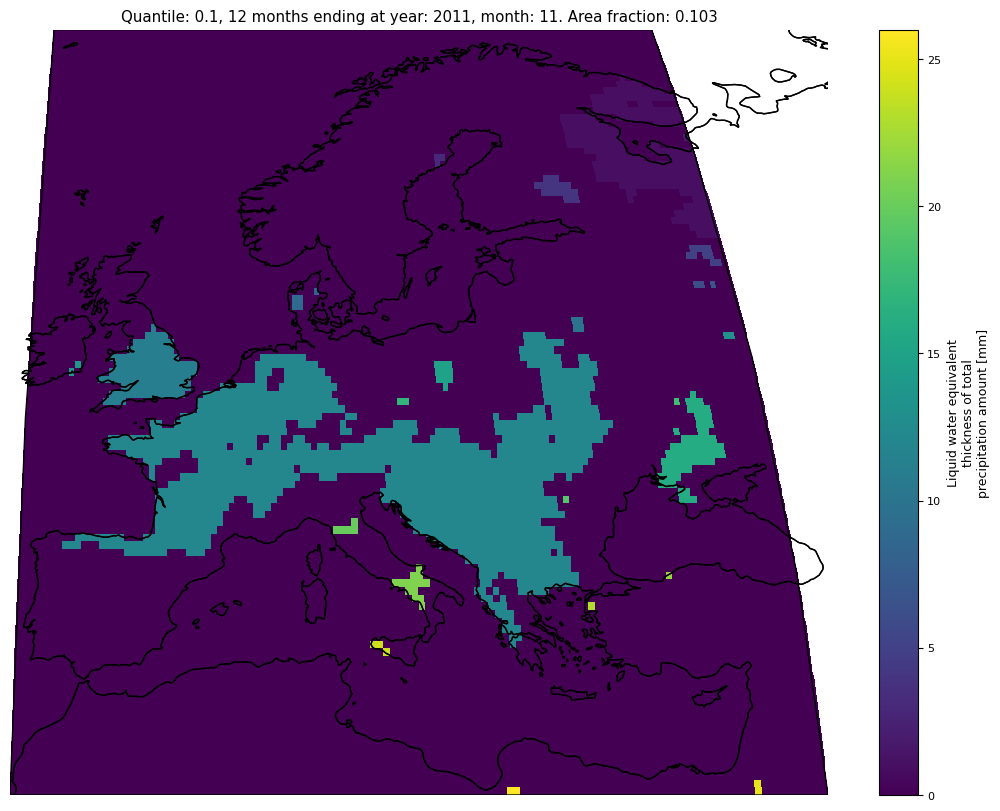

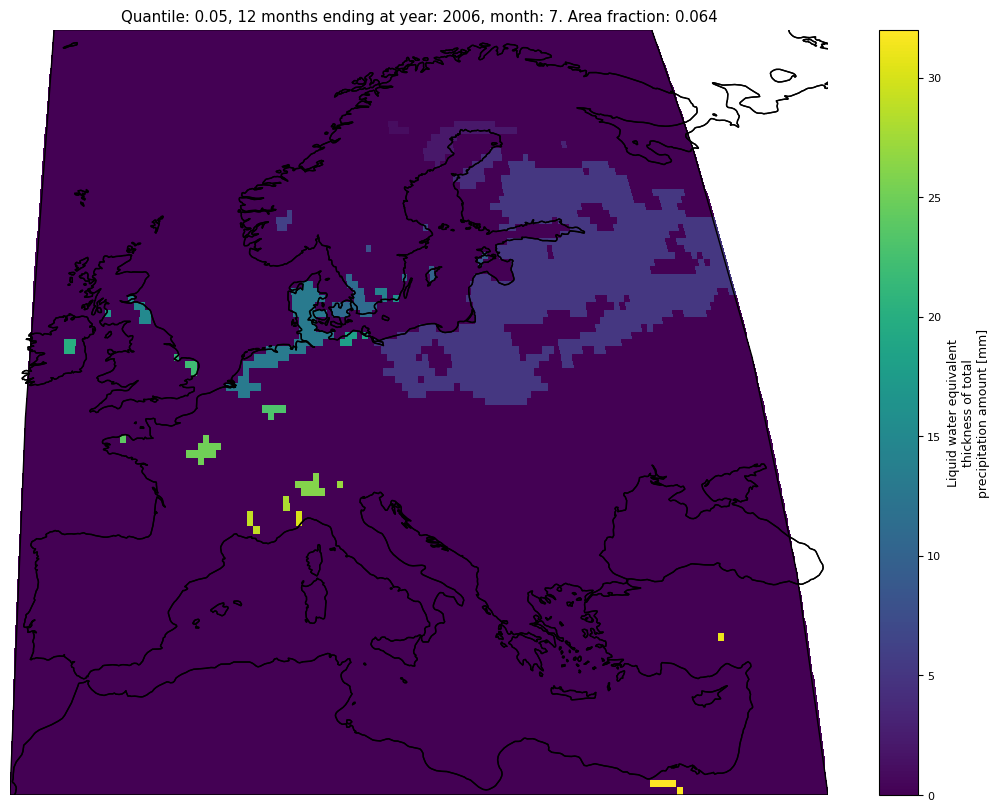

In [18]:
for q in labeled_images_gt["quantile"]:
    fig, axis = plt.subplots(
        1, 1, subplot_kw=dict(projection=ccrs.Robinson()), figsize=(12, 8)
    )
    map_plot_without_frame_with_bounds(ax=axis, da=labeled_images_gt.sel(quantile=q))
    axis.coastlines()
    axis.set_title(
        f"Quantile: {q.data}, {N_MONTHS_ROLLING} months ending at year: {labeled_images_gt.sel(quantile=q).year.data}, month: {labeled_images_gt.sel(quantile=q).month.data}. Area fraction: {overall_largest_cluster_area_gt.sel(quantile=q).data:.3f}"
    )
    plt.show()

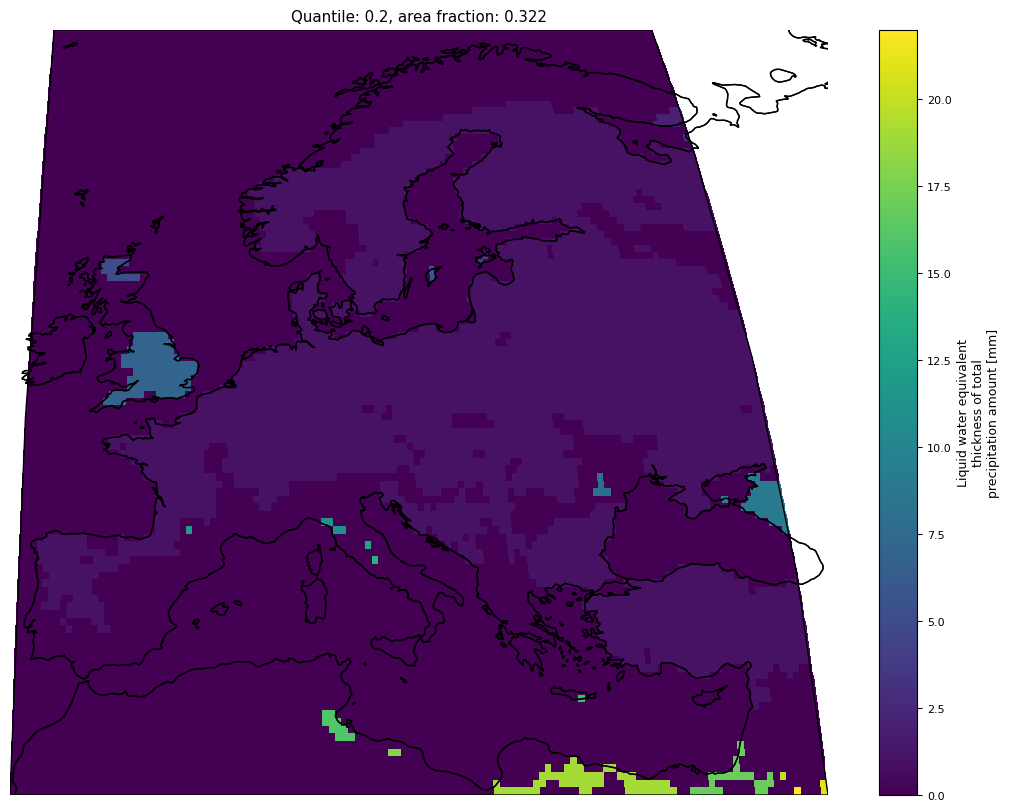

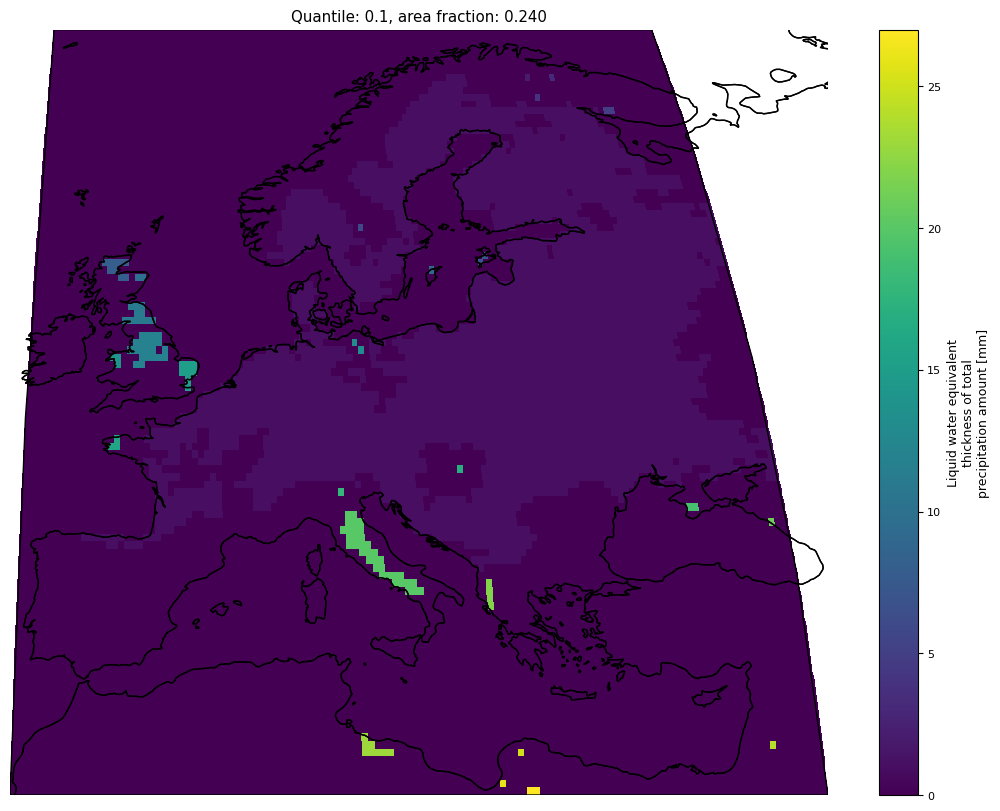

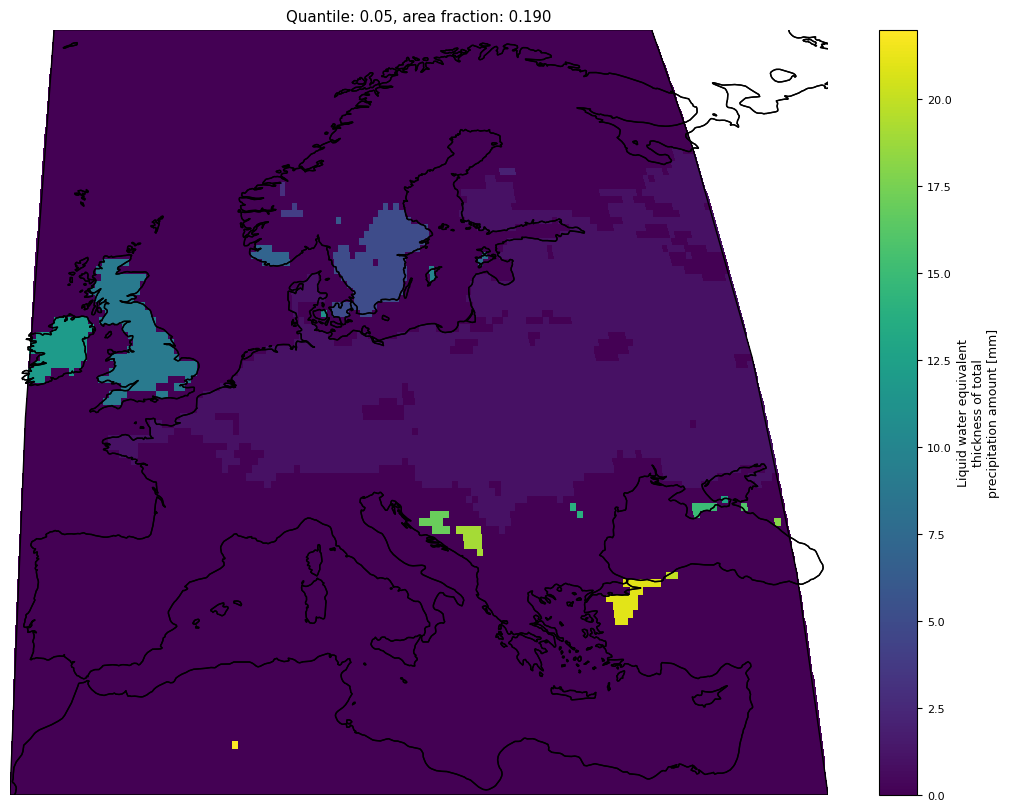

In [19]:
for q in labeled_images_wg["quantile"]:
    fig, axis = plt.subplots(
        1, 1, subplot_kw=dict(projection=ccrs.Robinson()), figsize=(12, 8)
    )
    map_plot_without_frame_with_bounds(
        ax=axis,
        da=labeled_images_wg.sel(seed=overall_largest_cluster_area_wg.seed).sel(
            quantile=q
        ),
    )
    axis.set_title(
        f"Quantile: {q.data}, area fraction: {overall_largest_cluster_area_wg.sel(quantile=q).squeeze().data:.3f}"
    )
    axis.coastlines()
    plt.show()

/tmp/ipykernel_1134402/1031385038.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


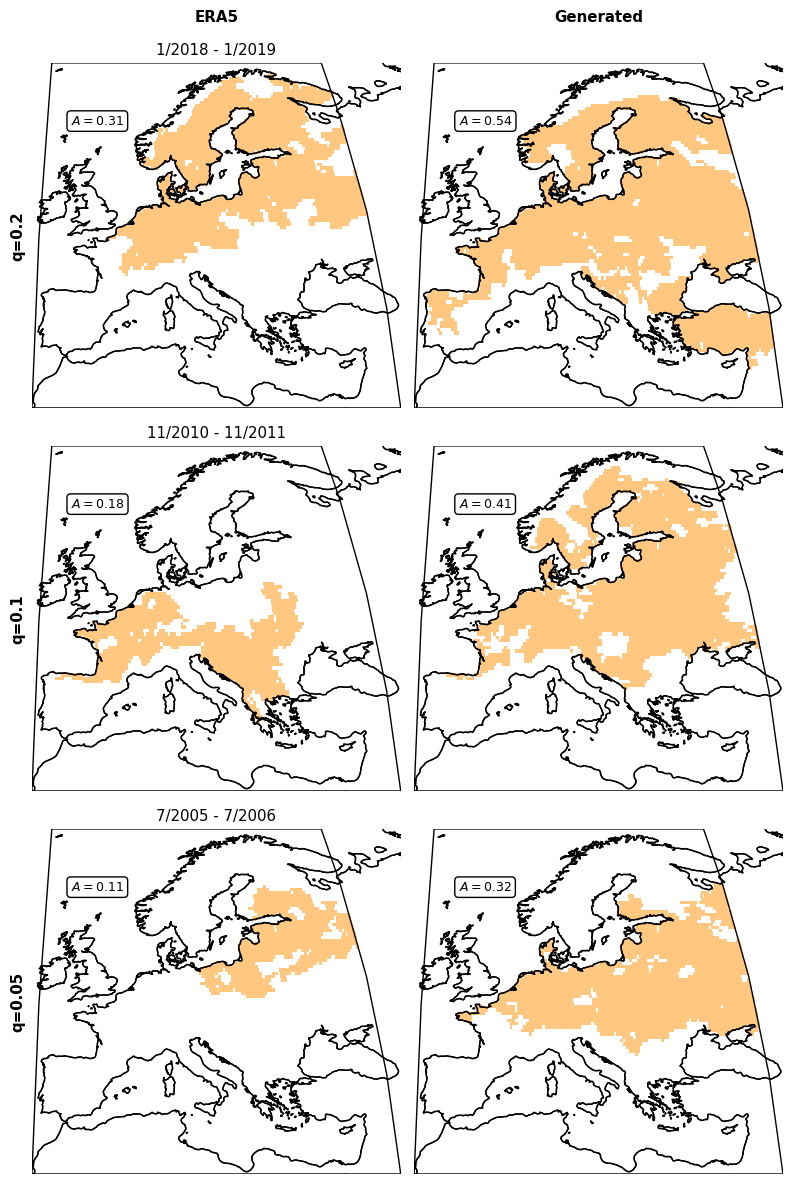

In [20]:
fig, axes = plt.subplots(
    len(labeled_images_wg_largest_component["quantile"]),
    2,
    subplot_kw=dict(projection=ccrs.Robinson()),
    figsize=(8, 12),
)

cmap = mpl.colormaps.get_cmap("copper")
cmap.set_under(alpha=0)
cmap.set_over(alpha=1)


for i, q in enumerate(labeled_images_wg_largest_component["quantile"]):
    map_plot_without_frame_with_bounds(
        ax=axes[i, 0],
        da=labeled_images_gt_largest_component.sel(quantile=q),
        cmap=cmap,
        vmin=0.5,
        vmax=1,
        add_colorbar=False,
    )

    map_plot_without_frame_with_bounds(
        ax=axes[i, 1],
        da=labeled_images_wg_largest_component.sel(
            seed=overall_largest_cluster_area_wg.seed
        ).sel(quantile=q),
        cmap=cmap,
        vmin=0.5,
        vmax=1,
        add_colorbar=False,
    )

    axes[i, 0].coastlines()
    axes[i, 1].coastlines()

    axes[i, 0].set_title(
        f"{overall_largest_cluster_area_gt.sel(quantile=q).month.data}/{overall_largest_cluster_area_gt.sel(quantile=q).year.data - 1} - {overall_largest_cluster_area_gt.sel(quantile=q).month.data}/{overall_largest_cluster_area_gt.sel(quantile=q).year.data}"
    )
    axes[i, 1].set_title("")

    transform = ccrs.PlateCarree()._as_mpl_transform(axes[i, 0])
    axes[i, 0].annotate(
        f"$A = {overall_largest_cluster_area_gt.sel(quantile=q).squeeze().data / fraction_land:.2f}$",
        xy=(-5.9408, 64.1470),
        xycoords=transform,
        ha="left",
        va="center",
        bbox=dict(boxstyle="round", edgecolor="black", facecolor="white"),
    )

    transform = ccrs.PlateCarree()._as_mpl_transform(axes[i, 1])
    axes[i, 1].annotate(
        f"$A = {overall_largest_cluster_area_wg.sel(quantile=q).squeeze().data / fraction_land:.2f}$",
        xy=(-5, 64.1470),
        xycoords=transform,
        ha="left",
        va="center",
        bbox=dict(boxstyle="round", edgecolor="black", facecolor="white"),
    )


font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    col_headers=["ERA5", "Generated"],
    row_headers=[
        f"q={q.data}" for q in labeled_images_wg_largest_component["quantile"]
    ],
    col_pad=30,
    **font_kwargs,
)
plt.tight_layout()

plt.savefig(os.path.join(paths["dir_images"], "rolling_drought.png"), dpi=300)
plt.show()

/tmp/ipykernel_1134402/2450107799.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


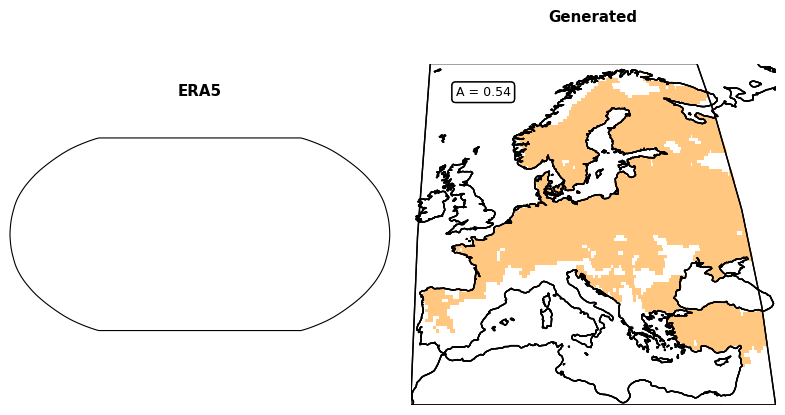

In [21]:
fig, axes = plt.subplots(
    1,
    2,
    subplot_kw=dict(projection=ccrs.Robinson()),
    figsize=(8, 4),
)

cmap = mpl.colormaps.get_cmap("copper")
cmap.set_under(alpha=0)
cmap.set_over(alpha=1)

subset_quantiles = labeled_images_wg_largest_component["quantile"].sel(
    quantile=slice(0.2, 0.2)
)

for _, q in enumerate(subset_quantiles):
    map_plot_without_frame_with_bounds(
        ax=axes[1],
        da=labeled_images_gt_largest_component.sel(quantile=q),
        cmap=cmap,
        vmin=0.5,
        vmax=1,
        add_colorbar=False,
    )

    map_plot_without_frame_with_bounds(
        ax=axes[-1],
        da=labeled_images_wg_largest_component.sel(
            seed=overall_largest_cluster_area_wg.seed
        ).sel(quantile=q),
        cmap=cmap,
        vmin=0.5,
        vmax=1,
        add_colorbar=False,
    )

    axes[1].coastlines()
    axes[-1].coastlines()

    axes[1].set_title(
        f"{overall_largest_cluster_area_gt.sel(quantile=q).month.data}/{overall_largest_cluster_area_gt.sel(quantile=q).year.data - 1} - {overall_largest_cluster_area_gt.sel(quantile=q).month.data}/{overall_largest_cluster_area_gt.sel(quantile=q).year.data}"
    )
    axes[-1].set_title("")

    transform = ccrs.PlateCarree()._as_mpl_transform(axes[1])
    axes[1].annotate(
        f"A = {overall_largest_cluster_area_gt.sel(quantile=q).squeeze().data / fraction_land:.2f}",
        xy=(-5, 68),
        xycoords=transform,
        ha="left",
        va="center",
        bbox=dict(boxstyle="round", edgecolor="black", facecolor="white"),
    )

    transform = ccrs.PlateCarree()._as_mpl_transform(axes[-1])
    axes[-1].annotate(
        f"A = {overall_largest_cluster_area_wg.sel(quantile=q).squeeze().data / fraction_land:.2f}",
        xy=(-5, 68),
        xycoords=transform,
        ha="left",
        va="center",
        bbox=dict(boxstyle="round", edgecolor="black", facecolor="white"),
    )


font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    col_headers=["ERA5", "Generated"],
    row_headers=[""],
    col_pad=30,
    **font_kwargs,
)
plt.tight_layout()

plt.savefig(os.path.join(paths["dir_images"], "rolling_drought_reduced.png"), dpi=300)
plt.show()

In [22]:
overall_largest_cluster_area_wg

<xarray.DataArray 'tp' (probability_model: 1, sigma: 1, blocksize: 1,
                        quantile: 3)> Size: 24B
array([[[[0.32154115, 0.24017767, 0.18955393]]]])
Coordinates:
  * probability_model  (probability_model) <U14 56B 'NoRestrictions'
  * sigma              (sigma) float64 8B 2.5
  * blocksize          (blocksize) int64 8B 30
  * quantile           (quantile) float64 24B 0.2 0.1 0.05
    seed               (probability_model, sigma, blocksize, quantile) int64 24B ...
    year               (probability_model, sigma, blocksize, quantile) int64 24B ...
    month              (probability_model, sigma, blocksize, quantile) int64 24B ...
    expver             <U4 16B '0001'
Attributes:
    units:          mm
    standard_name:  lwe_thickness_of_precipitation_amount
    cell_methods:   lead_time: maximum
    long_name:      Liquid water equivalent thickness of total precipitation ...

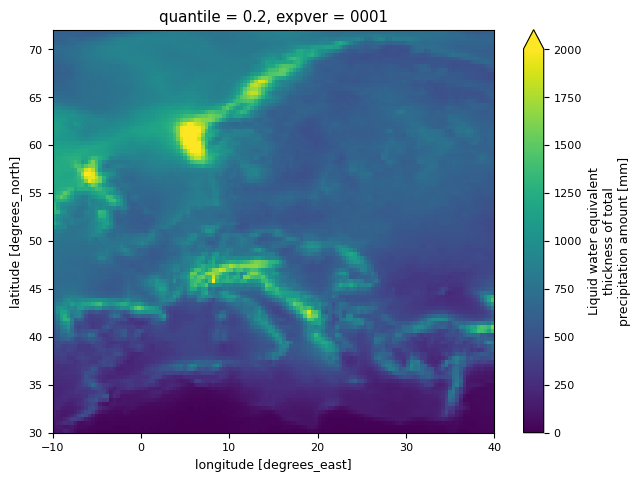

In [23]:
quantiles_gt.sel(quantile=q).plot(vmin=0, vmax=2000)

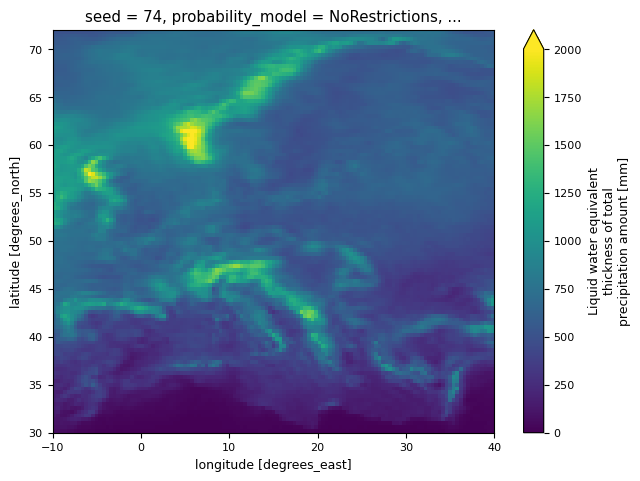

In [24]:
quantiles_wg.sel(seed=overall_largest_cluster_area_wg.seed).sel(quantile=q).plot(
    vmin=0, vmax=2000
)

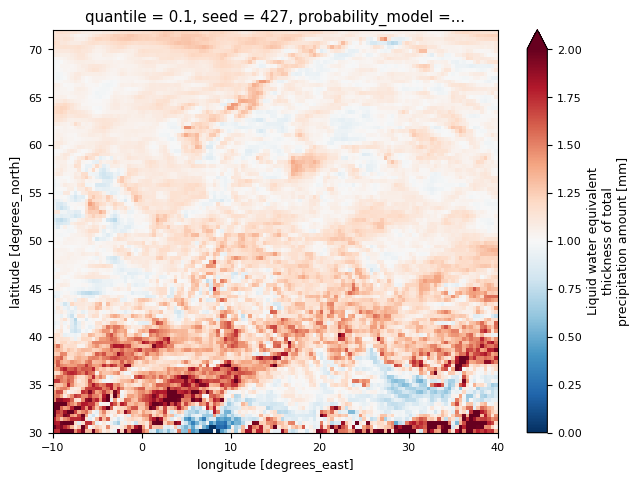

In [25]:
(
    quantiles_gt.sel(quantile=0.1)
    / quantiles_wg.sel(seed=overall_largest_cluster_area_wg.seed).sel(quantile=0.1)
).plot(cmap="RdBu_r", norm=mpl.colors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=2))

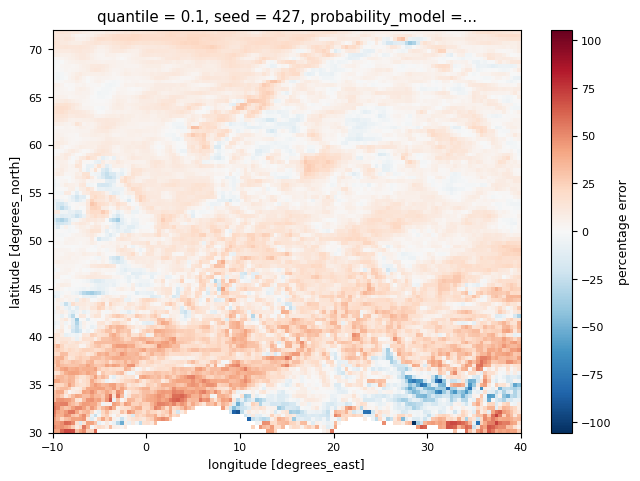

In [26]:
threshold = 10
da = (
    100
    * (
        quantiles_gt.sel(quantile=0.1)
        - quantiles_wg.sel(seed=overall_largest_cluster_area_wg.seed).sel(quantile=0.1)
    )
    / quantiles_gt.sel(quantile=0.1)
)

da.where(quantiles_gt.sel(quantile=0.1) > threshold).plot(
    cbar_kwargs={"label": "percentage error"}
)

In [27]:
max_fraction_area_wg = largest_cluster_area_wg.squeeze()

In [28]:
(max_fraction_area_wg > overall_largest_cluster_area_gt).any(dim=("time",)).mean(
    "seed"
).sel(quantile=q)

<xarray.DataArray 'tp' ()> Size: 8B
array(0.664)
Coordinates:
    probability_model  <U14 56B 'NoRestrictions'
    sigma              float64 8B 2.5
    blocksize          int64 8B 30
    quantile           float64 8B 0.2
    expver             <U4 16B '0001'
Attributes:
    units:          mm
    standard_name:  lwe_thickness_of_precipitation_amount
    long_name:      Liquid water equivalent thickness of total precipitation ...
    regrid_method:  conservative

### get stats on unprecedented event:

In [29]:
# largest event in each data set:
print("Quantile", overall_largest_cluster_area_wg["quantile"].data)
print(overall_largest_cluster_area_wg.data)
print(overall_largest_cluster_area_gt.data)

Quantile [0.2  0.1  0.05]
[[[[0.32154115 0.24017767 0.18955393]]]]
[0.18310647 0.10346378 0.06425667]


In [30]:
# what fraction of seeds have an event that is larger:
print("Quantile", overall_largest_cluster_area_wg["quantile"].data)
print(
    f"{
        (largest_cluster_area_wg.squeeze() > overall_largest_cluster_area_gt)
        .any('time')
        .mean('seed')
        .data
    }"
)

Quantile [0.2  0.1  0.05]
[0.664 0.832 0.864]


In [31]:
# what fraction of events are larger?
print("Quantile", overall_largest_cluster_area_wg["quantile"].data)
print(
    (largest_cluster_area_wg.squeeze() > overall_largest_cluster_area_gt)
    .mean(("time", "seed"))
    .data
)
print(
    (largest_cluster_area_wg.squeeze() > overall_largest_cluster_area_gt)
    .sum(("time", "seed"))
    .data
)

Quantile [0.2  0.1  0.05]
[0.009875   0.01488333 0.012975  ]
[1185 1786 1557]


In [32]:
overall_largest_cluster_area_gt

<xarray.DataArray 'tp' (quantile: 3)> Size: 24B
array([0.18310647, 0.10346378, 0.06425667])
Coordinates:
  * quantile  (quantile) float64 24B 0.2 0.1 0.05
    year      (quantile) int64 24B ...
    month     (quantile) int64 24B ...
    expver    <U4 16B '0001'
Attributes:
    long_name:      Liquid water equivalent thickness of total precipitation ...
    standard_name:  lwe_thickness_of_precipitation_amount
    regrid_method:  conservative
    units:          mm
    cell_methods:   lead_time: sum

## Are our WG connected component sizes statistically similar to ERA5?

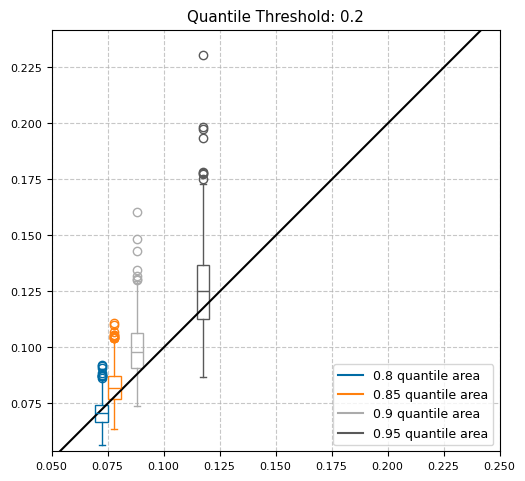

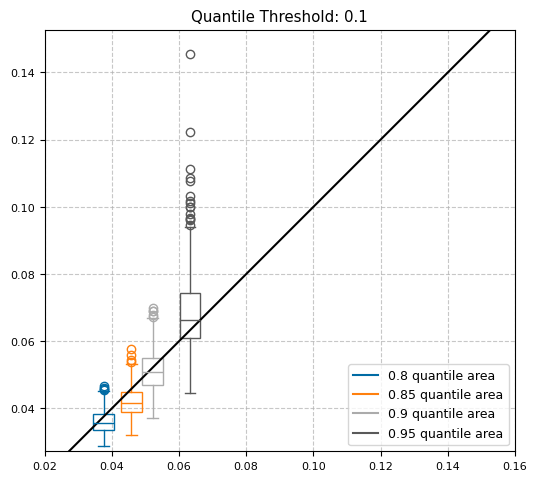

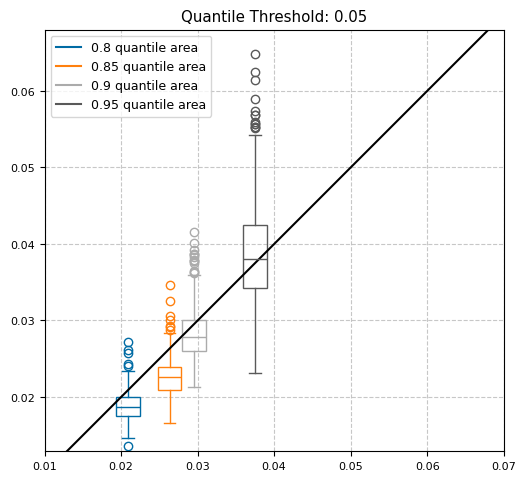

In [33]:
area_quantiles = np.linspace(0.8, 1, 5)[:-1]

for qt in largest_cluster_area_wg["quantile"]:
    quantiles_area_wg = (
        largest_cluster_area_wg.rename({"quantile": "quantile_threshold"})
        .sel(quantile_threshold=qt)
        .quantile(area_quantiles, "time")
        .squeeze()
    )
    quantiles_area_gt = (
        largest_cluster_area_gt.rename({"quantile": "quantile_threshold"})
        .sel(quantile_threshold=qt)
        .quantile(area_quantiles, "time")
        .squeeze()
    )

    fig = plt.figure()
    ax = plt.gca()

    x = quantiles_area_gt.squeeze()

    width = 0.98 * np.amin(
        (x.isel(quantile=slice(1, None)).data - x.isel(quantile=slice(None, -1)).data)
    )

    ys = quantiles_area_wg

    bp = plt.boxplot(ys.transpose(), positions=x, widths=width, patch_artist=True)

    # Define colors for each boxplot
    prop_cycle = plt.rcParams["axes.prop_cycle"]
    colors = prop_cycle.by_key()["color"]  # Or use a custom list of colors

    # Apply colors to each boxplot and collect legend handles
    legend_handles = []
    for i, (box, color) in enumerate(zip(bp["boxes"], colors)):
        # Set edge colors for all elements
        plt.setp(bp["boxes"][i], edgecolor=color, facecolor="none")
        plt.setp(bp["whiskers"][i * 2 : i * 2 + 2], color=color)
        plt.setp(bp["caps"][i * 2 : i * 2 + 2], color=color)
        plt.setp(bp["medians"][i], color=color)
        plt.setp(bp["fliers"][i], markeredgecolor=color, markerfacecolor="none")

        # Create legend handle
        legend_handles.append(
            plt.Line2D(
                [0], [0], color=color, label=f"{area_quantiles[i]:g} quantile area"
            )
        )  # Customize labels

    vmax = max(x.max(), ys.max()) * 1.05
    vmin = min(x.min(), ys.min()) * 0.95
    plt.plot(np.linspace(0, vmax, 2), np.linspace(0, vmax, 2), c="k")
    ax.set_aspect("equal")
    plt.xlim(vmin, vmax)
    plt.ylim(vmin, vmax)

    ax.set_xticks(ax.get_yticks())
    ax.set_xticklabels(ax.get_yticklabels())  # Format labels
    plt.title(f"Quantile Threshold: {qt:g}")
    ax.legend(handles=legend_handles, loc="best")

<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:111: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1134402/2693712704.py:111: SyntaxWarning: invalid escape sequence '\m'
  axes[-1, k].set_xlabel("$Q_A \mathrm{ERA5}_{2003-2023}$")


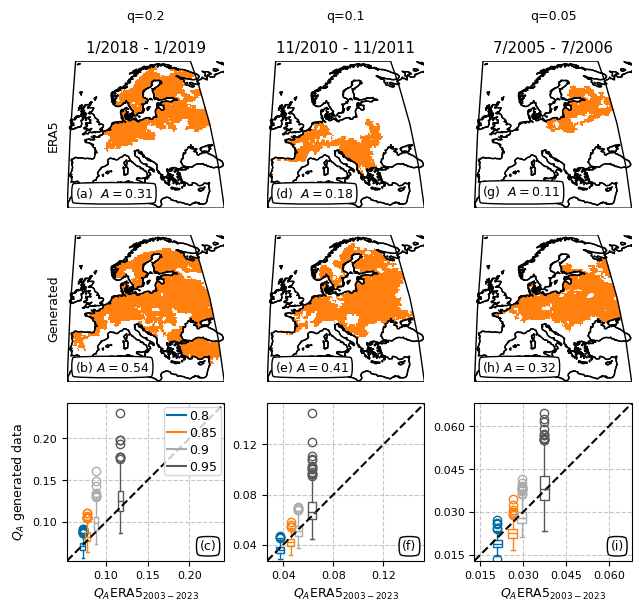

In [34]:
# combined plot
fig, axes = plt.subplots(
    3,
    len(labeled_images_wg_largest_component["quantile"]),
    subplot_kw=dict(projection=ccrs.Robinson()),
)
fig.set_figheight(6)

cmap = mpl.colors.ListedColormap("C1")
cmap.set_under(alpha=0)
cmap.set_over(alpha=1)

for i, q in enumerate(labeled_images_wg_largest_component["quantile"]):
    m = map_plot_without_frame_with_bounds(
        ax=axes[0, i],
        da=labeled_images_gt_largest_component.sel(quantile=q),
        cmap=cmap,
        vmin=0.5,
        vmax=1,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    m = map_plot_without_frame_with_bounds(
        ax=axes[1, i],
        da=labeled_images_wg_largest_component.sel(
            seed=overall_largest_cluster_area_wg.seed
        ).sel(quantile=q),
        cmap=cmap,
        vmin=0.5,
        vmax=1,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    axes[0, i].coastlines()
    axes[1, i].coastlines()

    axes[0, i].set_title(
        f"{overall_largest_cluster_area_gt.sel(quantile=q).month.data}/{overall_largest_cluster_area_gt.sel(quantile=q).year.data - 1} - {overall_largest_cluster_area_gt.sel(quantile=q).month.data}/{overall_largest_cluster_area_gt.sel(quantile=q).year.data}"
    )
    axes[1, i].set_title("")

    transform = ccrs.PlateCarree()._as_mpl_transform(axes[1, i])

    add_label_to_axes(
        axes[0, i],
        label=f"({ALPHABET[0 + 3 * i]})  $A = {overall_largest_cluster_area_gt.sel(quantile=q).squeeze().data / fraction_land:.2f}$",
        va="bottom",
        ha="left",
        ax_xpos=0.05,
        ax_ypos=0.05,
        edgecolor="k",
    )
    add_label_to_axes(
        axes[1, i],
        label=f"({ALPHABET[1 + 3 * i]}) $A = {overall_largest_cluster_area_wg.sel(quantile=q).squeeze().data / fraction_land:.2f}$",
        va="bottom",
        ha="left",
        ax_xpos=0.05,
        ax_ypos=0.05,
        edgecolor="k",
    )

# Q--Q plots
for k, qt in enumerate(largest_cluster_area_wg["quantile"]):
    quantiles_area_wg = (
        largest_cluster_area_wg.rename({"quantile": "quantile_threshold"})
        .sel(quantile_threshold=qt)
        .quantile(area_quantiles, "time")
        .squeeze()
    )
    quantiles_area_gt = (
        largest_cluster_area_gt.rename({"quantile": "quantile_threshold"})
        .sel(quantile_threshold=qt)
        .quantile(area_quantiles, "time")
        .squeeze()
    )

    x = quantiles_area_gt.squeeze()

    width = 0.98 * np.amin(
        (x.isel(quantile=slice(1, None)).data - x.isel(quantile=slice(None, -1)).data)
    )

    ys = quantiles_area_wg

    bp = axes[-1, k].boxplot(
        ys.transpose(), positions=x, widths=width, patch_artist=True
    )

    # Define colors for each boxplot
    prop_cycle = plt.rcParams["axes.prop_cycle"]
    colors = prop_cycle.by_key()["color"]  # Or use a custom list of colors

    # Apply colors to each boxplot and collect legend handles
    legend_handles = []
    for i, (box, color) in enumerate(zip(bp["boxes"], colors)):
        # Set edge colors for all elements
        plt.setp(bp["boxes"][i], edgecolor=color, facecolor="none")
        plt.setp(bp["whiskers"][i * 2 : i * 2 + 2], color=color)
        plt.setp(bp["caps"][i * 2 : i * 2 + 2], color=color)
        plt.setp(bp["medians"][i], color=color)
        plt.setp(bp["fliers"][i], markeredgecolor=color, markerfacecolor="none")

        # Create legend handle
        legend_handles.append(
            plt.Line2D([0], [0], color=color, label=f"${area_quantiles[i]:g}$")
        )  # Customize labels

    axes[-1, k].set_xlabel("$Q_A \mathrm{ERA5}_{2003-2023}$")
    if k == 0:
        axes[-1, k].set_ylabel("$Q_A$ generated data")
        axes[-1, k].legend(
            handles=legend_handles,
            loc="best",
            labelspacing=0.3,  # vertical space between entries
            handlelength=1.5,  # length of legend handles
            handletextpad=0.3,  # space between handle and text
            borderpad=0.2,  # padding inside legend border
            columnspacing=1.0,  # space between columns
            borderaxespad=0.3,  # padding between axes and legend
        )
    vmax = max(x.max(), ys.max()) * 1.05
    vmin = min(x.min(), ys.min()) * 0.95

    axes[-1, k].set_aspect("equal", adjustable="box")

    axes[-1, k].set_xlim(vmin, vmax)
    axes[-1, k].set_ylim(vmin, vmax)

    axes[-1, k].plot(
        np.linspace(vmin, vmax, 2),
        np.linspace(vmin, vmax, 2),
        c="k",
        linestyle="dashed",
    )

    n_ticks = 3  # Adjust as needed

    locator = MaxNLocator(nbins=4, prune="both")
    # Use the x-axis range to calculate ticks
    ticks = locator.tick_values(vmin, vmax)
    # Apply the same ticks to both axes
    axes[-1, k].set_xticks(ticks)
    axes[-1, k].set_yticks(ticks)
    axes[-1, k].set_xticklabels(axes[-1, k].get_yticklabels())

    add_label_to_axes(
        axes[-1, k],
        label=f"({ALPHABET[2 + 3 * k]})",
        va="bottom",
        ha="right",
        ax_xpos=0.95,
        ax_ypos=0.05,
        edgecolor="k",
    )

add_headers(
    fig,
    col_headers=[
        f"q={q.data}" for q in labeled_images_wg_largest_component["quantile"]
    ],
    row_headers=["ERA5", "Generated"] + [""],
    col_pad=30,
    # fontsize="large"
    # row_pad=10,
)

plt.savefig(os.path.join(paths["dir_images"], "rolling_drought_combined.pdf"), dpi=300)
plt.show()


<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:112: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1134402/3687885603.py:112: SyntaxWarning: invalid escape sequence '\m'
  axes[2].set_xlabel("$Q_A$ $\mathrm{ERA5_{2003-2023}}$")


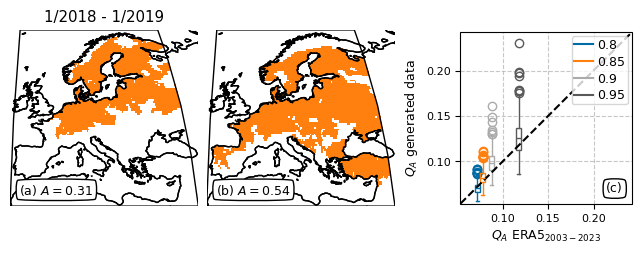

In [35]:
# combined reduced plot
fig, axes = plt.subplots(
    1, 3, subplot_kw=dict(projection=ccrs.Robinson()), width_ratios=[1.1, 1.1, 1]
)

fig.set_figheight(3)

qt = 0.2

cmap = mpl.colors.ListedColormap("C1")
cmap.set_under(alpha=0)
cmap.set_over(alpha=1)

subset_quantiles = labeled_images_wg_largest_component["quantile"].sel(
    quantile=slice(qt, qt)
)

for _, q in enumerate(subset_quantiles):
    m = map_plot_without_frame_with_bounds(
        ax=axes[0],
        da=labeled_images_gt_largest_component.sel(quantile=q),
        cmap=cmap,
        vmin=0.5,
        vmax=1,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    m = map_plot_without_frame_with_bounds(
        ax=axes[1],
        da=labeled_images_wg_largest_component.sel(
            seed=overall_largest_cluster_area_wg.seed
        ).sel(quantile=q),
        cmap=cmap,
        vmin=0.5,
        vmax=1,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    axes[0].coastlines()
    axes[1].coastlines()

    axes[0].set_title(
        f"{overall_largest_cluster_area_gt.sel(quantile=q).month.data}/{overall_largest_cluster_area_gt.sel(quantile=q).year.data - 1} - {overall_largest_cluster_area_gt.sel(quantile=q).month.data}/{overall_largest_cluster_area_gt.sel(quantile=q).year.data}"
    )
    axes[1].set_title("")

    add_label_to_axes(
        axes[0],
        label=f"(a) $A = {overall_largest_cluster_area_gt.sel(quantile=q).squeeze().data / fraction_land:.2f}$",
        ax_xpos=0.05,
        ax_ypos=0.05,
        ha="left",
        va="bottom",
        edgecolor="k",
    )

    add_label_to_axes(
        axes[1],
        label=f"(b) $A = {overall_largest_cluster_area_wg.sel(quantile=q).squeeze().data / fraction_land:.2f}$",
        ax_xpos=0.05,
        ax_ypos=0.05,
        ha="left",
        va="bottom",
        edgecolor="k",
    )

# Q--Q plots
quantiles_area_wg = (
    largest_cluster_area_wg.rename({"quantile": "quantile_threshold"})
    .sel(quantile_threshold=qt)
    .quantile(area_quantiles, "time")
    .squeeze()
)
quantiles_area_gt = (
    largest_cluster_area_gt.rename({"quantile": "quantile_threshold"})
    .sel(quantile_threshold=qt)
    .quantile(area_quantiles, "time")
    .squeeze()
)

x = quantiles_area_gt.squeeze()

width = 0.98 * np.amin(
    (x.isel(quantile=slice(1, None)).data - x.isel(quantile=slice(None, -1)).data)
)

ys = quantiles_area_wg

bp = axes[2].boxplot(ys.transpose(), positions=x, widths=width, patch_artist=True)

# Define colors for each boxplot
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]  # Or use a custom list of colors

# Apply colors to each boxplot and collect legend handles
legend_handles = []
for i, (box, color) in enumerate(zip(bp["boxes"], colors)):
    # Set edge colors for all elements
    plt.setp(bp["boxes"][i], edgecolor=color, facecolor="none")
    plt.setp(bp["whiskers"][i * 2 : i * 2 + 2], color=color)
    plt.setp(bp["caps"][i * 2 : i * 2 + 2], color=color)
    plt.setp(bp["medians"][i], color=color)
    plt.setp(bp["fliers"][i], markeredgecolor=color, markerfacecolor="none")

    # Create legend handle
    legend_handles.append(
        plt.Line2D([0], [0], color=color, label=f"${area_quantiles[i]:g}$")
    )  # Customize labels

axes[2].set_xlabel("$Q_A$ $\mathrm{ERA5_{2003-2023}}$")
axes[2].set_ylabel("$Q_A$ generated data")
axes[2].legend(
    handles=legend_handles,
    loc="best",
    labelspacing=0.3,  # vertical space between entries
    handlelength=1.5,  # length of legend handles
    handletextpad=0.3,  # space between handle and text
    borderpad=0.2,  # padding inside legend border
    columnspacing=1.0,  # space between columns
    borderaxespad=0.3,  # padding between axes and legend
)

vmax = max(x.max(), ys.max()) * 1.05
vmin = min(x.min(), ys.min()) * 0.95

axes[2].set_aspect("equal", adjustable="box")

axes[2].set_xlim(vmin, vmax)
axes[2].set_ylim(vmin, vmax)

axes[2].plot(
    np.linspace(vmin, vmax, 2),
    np.linspace(vmin, vmax, 2),
    c="k",
    linestyle="dashed",
)

n_ticks = 3  # Adjust as needed

locator = MaxNLocator(nbins=4, prune="both")
# Use the x-axis range to calculate ticks
ticks = locator.tick_values(vmin, vmax)
# Apply the same ticks to both axes
axes[2].set_xticks(ticks)
axes[2].set_yticks(ticks)
axes[2].set_xticklabels(axes[2].get_yticklabels())

add_label_to_axes(
    axes[2],
    label="(c)",
    ax_xpos=0.95,
    ax_ypos=0.05,
    ha="right",
    va="bottom",
    edgecolor="k",
)


plt.savefig(
    os.path.join(paths["dir_images"], "rolling_drought_reduced_extended.pdf"), dpi=300
)
plt.show()